<a href="https://colab.research.google.com/github/hsmu-jeongeun/medical-data-analysis/blob/main/11_tf_binding_prediction_RNA_inferience_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DeepChem 설치
Colab 노트북에 DeepChem 설치

tensorflow 기반 모델을 사용할 것이므로 pip install 명령에 [tensorflow]를 추가하여 필요한 종속성도 설치

In [1]:
# DeepChem 설치시 Keras 종속성 버전 일치를 위해 아래 환경 변수 설정 후 import 진행
import os
os.environ["TF_USE_LEGACY_KERAS"] = '1'

In [2]:
!pip install deepchem[tensorflow]

zsh:1: no matches found: deepchem[tensorflow]


In [3]:
!pip install tf_keras

  Using cached tf_keras-2.21.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached tensorflow-2.21.0-cp311-cp311-macosx_12_0_arm64.whl.metadata (4.4 kB)
  Using cached protobuf-7.34.1-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached ml_dtypes-0.5.4-cp311-cp311-macosx_10_9_universal2.whl.metadata (8.9 kB)
Using cached tf_keras-2.21.0-py3-none-any.whl (1.7 MB)
Using cached tensorflow-2.21.0-cp311-cp311-macosx_12_0_arm64.whl (223.4 MB)
Using cached ml_dtypes-0.5.4-cp311-cp311-macosx_10_9_universal2.whl (679 kB)
Using cached protobuf-7.34.1-cp310-abi3-macosx_10_9_universal2.whl (429 kB)
  Attempting uninstall: protobuf
    Found existing installation: protobuf 4.25.9
    Uninstalling protobuf-4.25.9:
      Successfully uninstalled protobuf-4.25.9
  Attempting uninstall: ml_dtypes
    Found existing installation: ml-dtypes 0.3.2
    Uninstalling ml-dtypes-0.3.2:
      Successfully uninstalled ml-dtypes-0.3.2
  Attempting uninstall: tensorflow
    Found existing instal

In [4]:
%pip install deepchem

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip uninstall tensorflow-metal -y

Found existing installation: tensorflow-metal 1.2.0
Uninstalling tensorflow-metal-1.2.0:
  Successfully uninstalled tensorflow-metal-1.2.0
Note: you may need to restart the kernel to use updated packages.


In [6]:
import deepchem as dc
dc.__version__

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!


Instructions for updating:
experimental_relax_shapes is deprecated, use reduce_retracing instead


Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'torch_geometric'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (/opt/anaconda3/envs/py311/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-geometric dependency, missing a dependency. cannot import name 'DMPNN' from 'deepchem.models.torch_models' (/opt/anaconda3/envs/py311/lib/python3.11/site-packages/deepchem/models/torch_models/__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'


'2.8.0'

### warning 메시지 생략

In [7]:
import warnings
warnings.filterwarnings(action='ignore')

# 전사인자 결합 예측 모델

- JUND 전사 인자의 결합 예측을 위한 CNN 모델 생성
- 2차원 이미지가 아닌 1차원 데이터 사용하는 CNN 모델

### 라이브러리 불러오기

In [8]:
import deepchem as dc
import tensorflow as tf
import tensorflow.keras.layers as layers

### 데이터 불러오기 및 확인

In [9]:
train = dc.data.DiskDataset('/Users/pitzsb1/Documents/train_dataset')
valid = dc.data.DiskDataset('/Users/pitzsb1/Documents/valid_dataset')

In [10]:
train.X.shape

(276216, 101, 4)

In [11]:
train.y.shape

(276216, 1)

In [12]:
train

<DiskDataset X.shape: (276216, 101, 4), y.shape: (276216, 1), w.shape: (276216, 1), task_names: [0]>

### 모델 생성

In [ ]:
features = tf.keras.Input(shape=(101, 4))
prev = features

for i in range(3):
    prev = layers.Conv1D(filters=15, kernel_size=10, activation=tf.nn.relu, padding='same')(prev)
    prev = layers.Dropout(rate=0.5)(prev) # Dropout 레이어는 과적합을 방지하기 위해 신경망의 일부 뉴런을 무작위로 비활성화하는 역할을 하며, rate=0.5는 50%의 뉴런을 비활성화하도록 설정

logits = layers.Dense(units=1)(layers.Flatten()(prev)) # Dense 레이어는 입력을 1차원으로 평탄화한 후, 1개의 유닛을 사용하여 출력(logits)을 생성
output = layers.Activation(tf.math.sigmoid)(logits) # sigmoid 활성화 함수를 사용하여 logits을 0과 1 사이의 확률로 변환하여 최종 출력(output)을 생성

In [ ]:
keras_model = tf.keras.Model(inputs=features, outputs=[output, logits]) 

model = dc.models.KerasModel(
    keras_model,
    loss=dc.models.losses.SigmoidCrossEntropy(),
    output_types=['prediction', 'loss'],
    batch_size=1000,
    model_dir='tf')

### 모델 학습 및 평가

In [ ]:
metric = dc.metrics.Metric(dc.metrics.roc_auc_score) 
for i in range(20):
    model.fit(train, nb_epoch=10)
    print(model.evaluate(train, [metric]))
    print(model.evaluate(valid, [metric]))

{'roc_auc_score': 0.5786756254039145}
{'roc_auc_score': 0.4882249195457988}
{'roc_auc_score': 0.7454871209839637}
{'roc_auc_score': 0.7235778123708818}
{'roc_auc_score': 0.7868077939222962}
{'roc_auc_score': 0.7392221053919157}
{'roc_auc_score': 0.8088671557340625}
{'roc_auc_score': 0.7320938352777677}
{'roc_auc_score': 0.8127900723455292}
{'roc_auc_score': 0.7447447279936792}
{'roc_auc_score': 0.8224003430795941}
{'roc_auc_score': 0.7397554120565955}
{'roc_auc_score': 0.8313888846935509}
{'roc_auc_score': 0.7435002129640735}
{'roc_auc_score': 0.8372969926257953}
{'roc_auc_score': 0.7412911340406636}
{'roc_auc_score': 0.862168784617868}
{'roc_auc_score': 0.7358447123351421}
{'roc_auc_score': 0.8582782899624892}
{'roc_auc_score': 0.7337473947262207}


KeyboardInterrupt: 

# 모델 수정
- Dense층 학습 시 전사 인자 조절에 관여하는 RNA 간섭 feature 추가
- feature 레이어가 2개라 fit함수 사용 불가능
- 배치별 반복 학습 수행
- iterbatches() 함수를 통해 모델에 필요한 입력 데이터 배치별 처리

In [17]:
import numpy as np

In [18]:
span_accessibility = {}
for line in open('/content/drive/MyDrive/2025-1/md/data/accessibility.txt'):
    fields = line.split()
    span_accessibility[fields[0]] = float(fields[1])

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/2025-1/md/data/accessibility.txt'

In [19]:
span_accessibility

{}

In [20]:
features = tf.keras.Input(shape=(101, 4))
accessibility = tf.keras.Input(shape=(1,))

prev = features
for i in range(3):
    prev = layers.Conv1D(filters=15, kernel_size=10, activation=tf.nn.relu, padding='same')(prev)
    prev = layers.Dropout(rate=0.5)(prev)

prev = layers.Concatenate()([layers.Flatten()(prev), accessibility])

logits = layers.Dense(units=1)(prev)
output = layers.Activation(tf.math.sigmoid)(logits)
keras_model = tf.keras.Model(inputs=[features, accessibility], outputs=[output, logits])

model = dc.models.KerasModel(
    keras_model,
    loss=dc.models.losses.SigmoidCrossEntropy(),
    output_types=['prediction', 'loss'],
    batch_size=1000,
    model_dir='chromatin')

In [21]:
def generate_batches(dataset, epochs):
    for epoch in range(epochs):
        for X, y, w, ids in dataset.iterbatches(batch_size=1000, pad_batches=True):
            yield ([X, np.array([span_accessibility[id] for id in ids])], [y], [w])

### 성능 평가

In [23]:
metric = dc.metrics.Metric(dc.metrics.roc_auc_score)
for i in range(20):
    try:
        model.fit_generator(generate_batches(train, epochs=10))
    except KeyError as e:
        print(f"Warning: Missing accessibility data for {e}. Check if span_accessibility is populated correctly.")
        continue
    print(model.evaluate_generator(generate_batches(train, 1), [metric]))
    print(model.evaluate_generator(generate_batches(valid, 1), [metric]))

# RNA 간섭 예측 모델
- RNA 서열을 입력 데이터로 사용해 RNA 간섭의 효과 예측하는 CNN 모델

In [24]:
import matplotlib.pyplot as plt

### 데이터 불러오기 및 확인

In [26]:
train = dc.data.DiskDataset('/Users/pitzsb1/Documents/train_siRNA')
valid = dc.data.DiskDataset('/Users/pitzsb1/Documents/valid_siRNA')

In [27]:
train.X.shape

(2187, 21, 4)

In [28]:
train.y.shape

(2187, 1)

In [29]:
train.X

array([[[0, 1, 0, 0],
        [0, 0, 0, 1],
        [0, 1, 0, 0],
        ...,
        [0, 0, 0, 1],
        [0, 1, 0, 0],
        [0, 0, 0, 1]],

       [[0, 1, 0, 0],
        [0, 1, 0, 0],
        [1, 0, 0, 0],
        ...,
        [0, 1, 0, 0],
        [0, 0, 0, 1],
        [0, 1, 0, 0]],

       [[0, 0, 0, 1],
        [0, 1, 0, 0],
        [0, 1, 0, 0],
        ...,
        [0, 0, 0, 1],
        [0, 1, 0, 0],
        [0, 0, 0, 1]],

       ...,

       [[1, 0, 0, 0],
        [0, 0, 1, 0],
        [1, 0, 0, 0],
        ...,
        [1, 0, 0, 0],
        [1, 0, 0, 0],
        [1, 0, 0, 0]],

       [[0, 0, 1, 0],
        [1, 0, 0, 0],
        [0, 1, 0, 0],
        ...,
        [1, 0, 0, 0],
        [0, 0, 0, 1],
        [1, 0, 0, 0]],

       [[0, 0, 0, 1],
        [0, 0, 1, 0],
        [0, 0, 0, 1],
        ...,
        [0, 1, 0, 0],
        [1, 0, 0, 0],
        [1, 0, 0, 0]]], dtype=int8)

### 모델 생성

In [ ]:
features = tf.keras.Input(shape=(21, 4))
prev = features # prev는 모델의 중간 출력을 저장하는 변수로, 초기에는 입력(features)과 동일하게 설정
for i in range(2):
    prev = layers.Conv1D(filters=10, kernel_size=10, activation=tf.nn.relu, padding='same')(prev)
    prev = layers.Dropout(rate=0.3)(prev)
output = layers.Dense(units=1, activation=tf.math.sigmoid)(layers.Flatten()(prev))
keras_model = tf.keras.Model(inputs=features, outputs=output)
model = dc.models.KerasModel(
    keras_model,
    loss=dc.models.losses.L2Loss(),
    batch_size=1000,
    model_dir='rnai') # 모델 저장 디렉토리 설정

### 모델 학습 및 평가

In [31]:
train_scores = []
valid_scores = []

In [ ]:
metric = dc.metrics.Metric(dc.metrics.pearsonr, mode='regression') 
# Pearson 상관 계수는 -1에서 1 사이의 값을 가지며, 1에 가까울수록 강한 양의 상관 관계

for i in range(20):
    model.fit(train, nb_epoch=10)
    train_score = model.evaluate(train, [metric])['pearsonr'] 
    valid_score = model.evaluate(valid, [metric])['pearsonr']

    train_scores.append(train_score)
    valid_scores.append(valid_score)

    print(train_score)
    print(valid_score)

0.07643572553210566
-0.06648647074380509
0.3169476606089878
0.16070290532752327
0.5041082345071961
0.37786019948637395
0.5792216255153138
0.49292784292528585
0.607840104528945
0.527160195636597
0.6257024852358972
0.5387818861758866
0.6397661660410154
0.5460029723656354
0.6500781349323634
0.5488151979836698
0.6601269568604192
0.5545984366531518
0.6699182261175358
0.557854788669951
0.6790276849087918
0.5666041782038109
0.6875023126371571
0.5713802782323644
0.6937971140302653
0.5751806743218497
0.6991130006790549
0.5809037073839605
0.7057315645168112
0.5868466156527727
0.7105598953075374
0.5919019328168056
0.7141461582368102
0.593134644255221
0.7184510852674532
0.5965520964647644
0.7216882123210865
0.5961960758629958
0.7255803026604422
0.5991843859823451


### 모델 성능 시각화

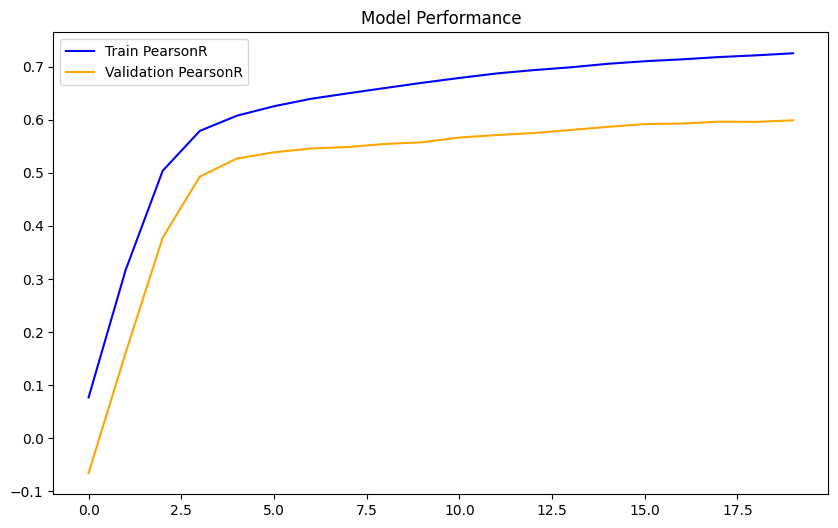

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_scores, label='Train PearsonR', color='blue') 
plt.plot(valid_scores, label='Validation PearsonR', color='orange')

plt.title('Model Performance')
plt.legend()
plt.show() 